# 🎸 Musical Instrument Recognition
## Deep Learning Course Project

This notebook covers the **full progression** taught in the course — from classical ML baselines
up through modern, optimised CNN architectures:

| Phase | Method | Key Concept |
|-------|--------|-------------|
| **1** | HOG + SVM / Random Forest | Classical feature engineering baseline |
| **2** | Custom CNN (from scratch) | Representation learning, depth |
| **3** | CNN + Regularisation | Image Augmentation + Dropout |
| **4** | Transfer Learning – MobileNetV2 | Depthwise Separable Convolutions, edge deployment |
| **5** | Transfer Learning – EfficientNetB0 | Compound Scaling |
| **6** | Comparison & Analysis | Accuracy, params, latency trade-offs |

**Dataset:** [Musical Instruments Image Classification](https://www.kaggle.com/datasets/gpiosenka/musical-instruments-image-classification) — 30 classes

In [ ]:
# Run once to install any missing packages
!pip install kagglehub scikit-image --quiet

In [ ]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os
import time
import warnings
warnings.filterwarnings('ignore')

# ── Data & Numerics ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import cv2
import kagglehub
from skimage.feature import hog

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Classical ML ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# ── Deep Learning (TensorFlow / Keras) ───────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.20.0
GPU available      : True


In [ ]:
# ── Download Dataset ──────────────────────────────────────────────────────────
path = kagglehub.dataset_download("gpiosenka/musical-instruments-image-classification")
print("Dataset path:", path)

# ── Global Configuration ──────────────────────────────────────────────────────
IMG_SIZE     = 128          # pixels (H x W)
BATCH_SIZE   = 32
EPOCHS_CNN   = 30           # custom CNN training budget
EPOCHS_TL    = 20           # transfer learning fine-tune budget
NUM_CLASSES  = 30

TRAIN_DIR = os.path.join(path, 'train')
VALID_DIR = os.path.join(path, 'valid')
TEST_DIR  = os.path.join(path, 'test')

# ── 30 Instrument Classes ─────────────────────────────────────────────────────
CLASSES = [
    "Didgeridoo", "Tambourine", "Xylophone", "acordian", "alphorn",
    "bagpipes", "banjo", "bongo drum", "casaba", "castanets",
    "clarinet", "clavichord", "concertina", "drums", "dulcimer",
    "flute", "guiro", "guitar", "harmonica", "harp",
    "marakas", "ocarina", "piano", "saxaphone", "sitar",
    "steel drum", "trombone", "trumpet", "tuba", "violin"
]

print(f"\nNumber of classes : {len(CLASSES)}")
print(f"Classes           : {CLASSES}")

Using Colab cache for faster access to the 'musical-instruments-image-classification' dataset.
Dataset path: /kaggle/input/musical-instruments-image-classification

Number of classes : 30
Classes           : ['Didgeridoo', 'Tambourine', 'Xylophone', 'acordian', 'alphorn', 'bagpipes', 'banjo', 'bongo drum', 'casaba', 'castanets', 'clarinet', 'clavichord', 'concertina', 'drums', 'dulcimer', 'flute', 'guiro', 'guitar', 'harmonica', 'harp', 'marakas', 'ocarina', 'piano', 'saxaphone', 'sitar', 'steel drum', 'trombone', 'trumpet', 'tuba', 'violin']


In [ ]:
def count_images(base_dir, classes):
    """Count images per class in a split directory."""
    counts = {}
    for cls in classes:
        folder = os.path.join(base_dir, cls)
        if os.path.exists(folder):
            counts[cls] = len([
                f for f in os.listdir(folder)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
        else:
            counts[cls] = 0
    return counts

train_counts = count_images(TRAIN_DIR, CLASSES)
valid_counts = count_images(VALID_DIR, CLASSES)
test_counts  = count_images(TEST_DIR,  CLASSES)

df_counts = pd.DataFrame({
    'Train': train_counts,
    'Valid': valid_counts,
    'Test' : test_counts
})
df_counts['Total'] = df_counts.sum(axis=1)

print("Per-class image counts:")
print(df_counts.to_string())
print(f"\nDataset totals → Train: {df_counts['Train'].sum()}  "
      f"Valid: {df_counts['Valid'].sum()}  Test: {df_counts['Test'].sum()}")

Per-class image counts:
            Train  Valid  Test  Total
Didgeridoo    145      5     5    155
Tambourine    275      5     5    285
Xylophone     205      5     5    215
acordian      209      5     5    219
alphorn       134      5     5    144
bagpipes      137      5     5    147
banjo         155      5     5    165
bongo drum    141      5     5    151
casaba        218      5     5    228
castanets     130      5     5    140
clarinet      133      5     5    143
clavichord    207      5     5    217
concertina    152      5     5    162
drums         184      5     5    194
dulcimer      126      5     5    136
flute         194      5     5    204
guiro         117      5     5    127
guitar        137      5     5    147
harmonica     142      5     5    152
harp          173      5     5    183
marakas       114      5     5    124
ocarina       127      5     5    137
piano         119      5     5    129
saxaphone     127      5     5    137
sitar         216      5  

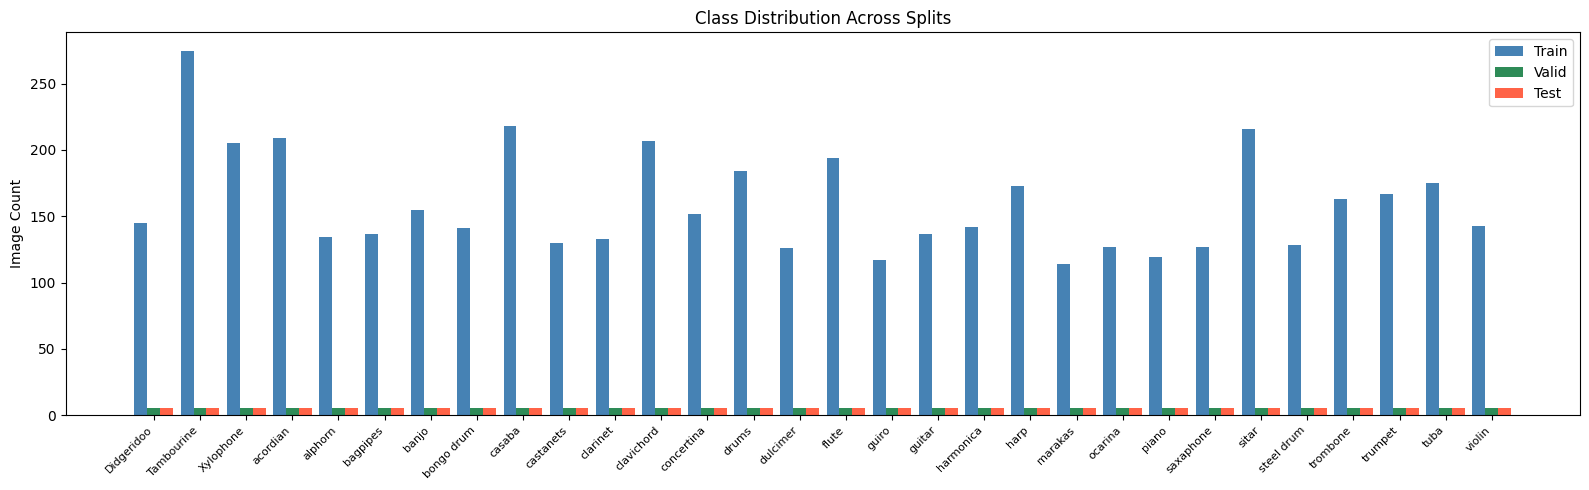

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(NUM_CLASSES)
w = 0.28
ax.bar(x - w, df_counts['Train'], width=w, label='Train', color='steelblue')
ax.bar(x,     df_counts['Valid'],  width=w, label='Valid',  color='seagreen')
ax.bar(x + w, df_counts['Test'],   width=w, label='Test',   color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Image Count')
ax.set_title('Class Distribution Across Splits')
ax.legend()
plt.tight_layout()
plt.show()

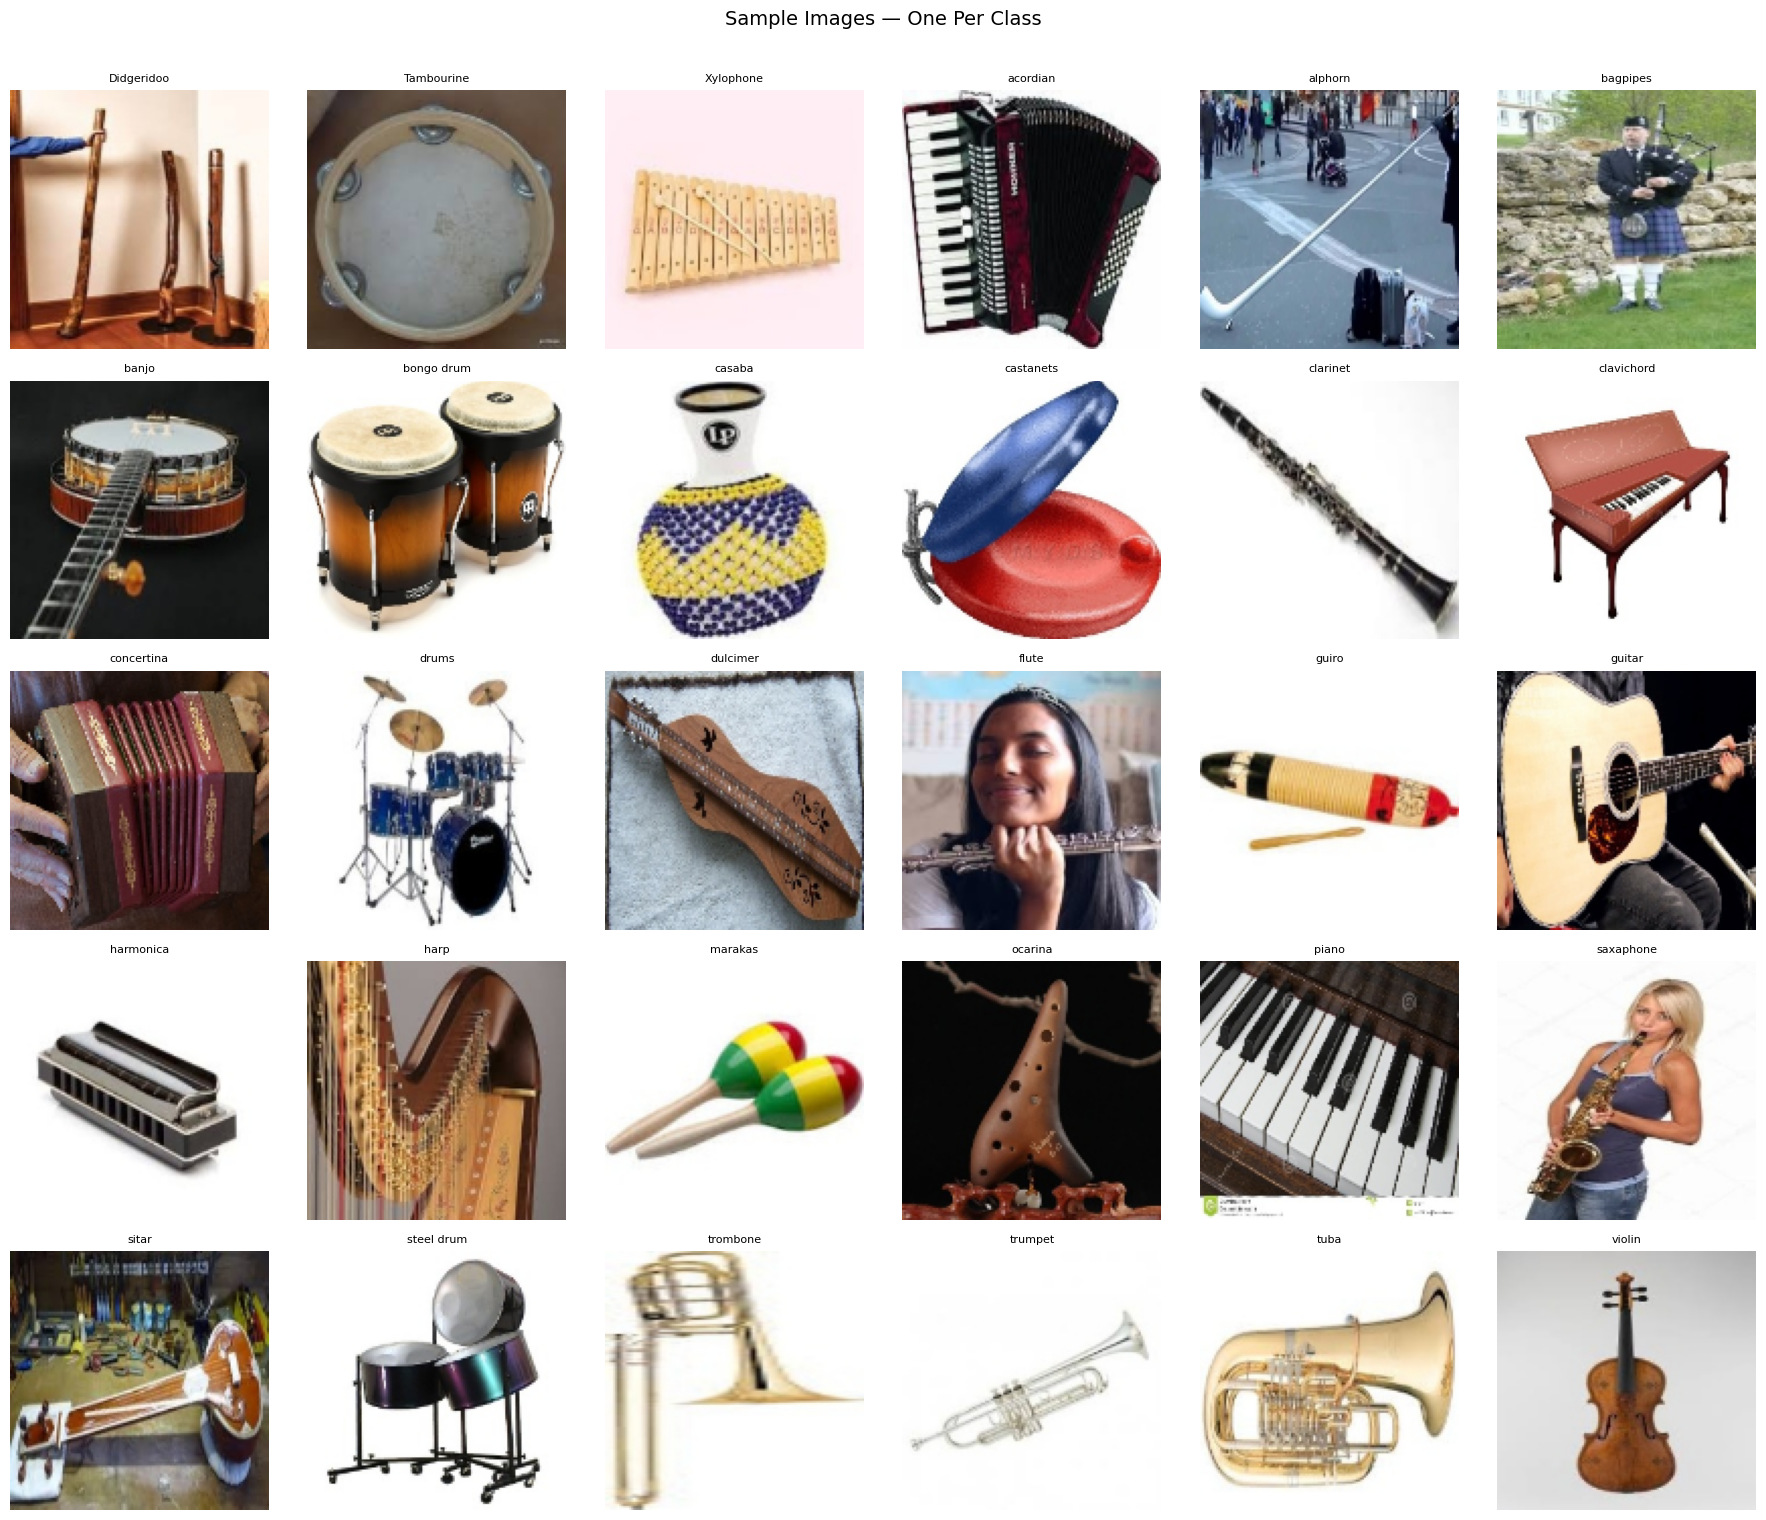

In [ ]:
# Show one random sample image per class
fig, axes = plt.subplots(5, 6, figsize=(18, 15))
axes = axes.flatten()

for idx, cls in enumerate(CLASSES):
    folder = os.path.join(TRAIN_DIR, cls)
    files  = os.listdir(folder)
    sample = cv2.imread(os.path.join(folder, np.random.choice(files)))
    sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)
    sample = cv2.resize(sample, (IMG_SIZE, IMG_SIZE))
    axes[idx].imshow(sample)
    axes[idx].set_title(cls, fontsize=8)
    axes[idx].axis('off')

# hide the 31st unused subplot
for i in range(NUM_CLASSES, len(axes)):
    axes[i].axis('off')

plt.suptitle('Sample Images — One Per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

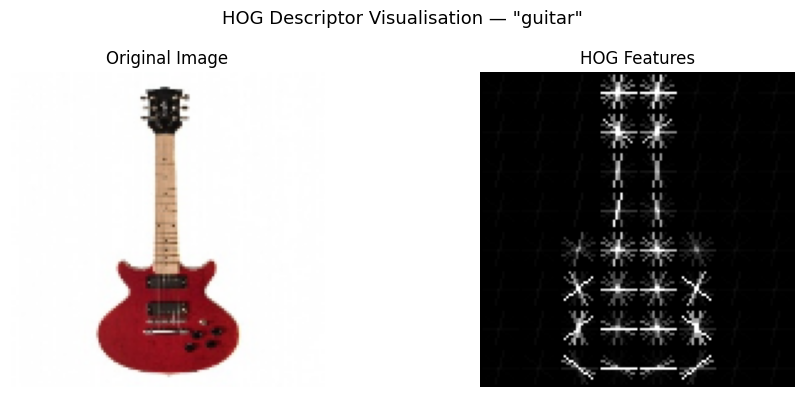

HOG feature vector length: 1764


In [ ]:
from skimage.feature import hog
from skimage import exposure

sample_cls   = 'guitar'
sample_folder = os.path.join(TRAIN_DIR, sample_cls)
sample_file   = os.path.join(sample_folder, os.listdir(sample_folder)[0])

img_bgr = cv2.imread(sample_file)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

hog_feats, hog_image = hog(
    img_gray,
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    visualize=True
)
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(img_rgb); ax1.set_title('Original Image'); ax1.axis('off')
ax2.imshow(hog_image_rescaled, cmap='gray'); ax2.set_title('HOG Features'); ax2.axis('off')
plt.suptitle(f'HOG Descriptor Visualisation — "{sample_cls}"', fontsize=13)
plt.tight_layout()
plt.show()
print(f"HOG feature vector length: {hog_feats.shape[0]}")

In [ ]:
# ── Load all images from train / valid / test ─────────────────────────────────
all_images, all_labels = [], []

for split in ['train', 'valid', 'test']:
    split_path = os.path.join(path, split)
    if not os.path.exists(split_path):
        print(f"[WARN] '{split}' directory not found — skipping.")
        continue
    for idx, cls in enumerate(CLASSES):
        folder = os.path.join(split_path, cls)
        if not os.path.exists(folder):
            continue
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            img   = cv2.imread(fpath)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            all_images.append(img)
            all_labels.append(idx)

all_images = np.array(all_images)
all_labels = np.array(all_labels)
print(f"Total images loaded : {len(all_images)}")
print(f"Label array shape   : {all_labels.shape}")

Total images loaded : 5093
Label array shape   : (5093,)


In [ ]:
# ── HOG Feature Extraction ────────────────────────────────────────────────────
hog_features = []
for img in all_images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    feat = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )
    hog_features.append(feat)

hog_features = np.array(hog_features)
print(f"HOG feature matrix shape : {hog_features.shape}")

# ── Train / Test Split ────────────────────────────────────────────────────────
X_train_hog, X_test_hog, y_train_hog, y_test_hog = train_test_split(
    hog_features, all_labels,
    test_size=0.2, random_state=SEED, stratify=all_labels
)

# ── Standardise ───────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_hog = scaler.fit_transform(X_train_hog)
X_test_hog  = scaler.transform(X_test_hog)

print(f"Train size : {X_train_hog.shape[0]}  |  Test size : {X_test_hog.shape[0]}")

HOG feature matrix shape : (5093, 1764)
Train size : 4074  |  Test size : 1019


In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────────
print("Training Random Forest …")
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train_hog, y_train_hog)
y_pred_rf  = rf.predict(X_test_hog)
acc_rf     = accuracy_score(y_test_hog, y_pred_rf)
time_rf    = time.time() - t0
print(f"  ✓ RF Accuracy : {acc_rf:.4f}  ({time_rf:.1f}s)")

# ── SVM ───────────────────────────────────────────────────────────────────────
print("Training SVM …")
t0 = time.time()
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED)
svm.fit(X_train_hog, y_train_hog)
y_pred_svm = svm.predict(X_test_hog)
acc_svm    = accuracy_score(y_test_hog, y_pred_svm)
time_svm   = time.time() - t0
print(f"  ✓ SVM Accuracy : {acc_svm:.4f}  ({time_svm:.1f}s)")

Training Random Forest …
  ✓ RF Accuracy : 0.4701  (25.8s)
Training SVM …
  ✓ SVM Accuracy : 0.5918  (40.3s)



 Random Forest — Classification Report
              precision    recall  f1-score   support

  Didgeridoo       0.09      0.06      0.07        31
  Tambourine       0.49      0.67      0.57        57
   Xylophone       0.49      0.51      0.50        43
    acordian       0.45      0.70      0.55        44
     alphorn       0.29      0.59      0.39        29
    bagpipes       0.12      0.07      0.09        29
       banjo       0.71      0.45      0.56        33
  bongo drum       0.86      0.83      0.85        30
      casaba       0.41      0.67      0.51        46
   castanets       0.70      0.50      0.58        28
    clarinet       0.50      0.14      0.22        29
  clavichord       0.36      0.73      0.48        44
  concertina       0.43      0.62      0.51        32
       drums       0.61      0.92      0.73        39
    dulcimer       0.20      0.04      0.06        27
       flute       0.22      0.20      0.21        41
       guiro       0.50      0.20      0.

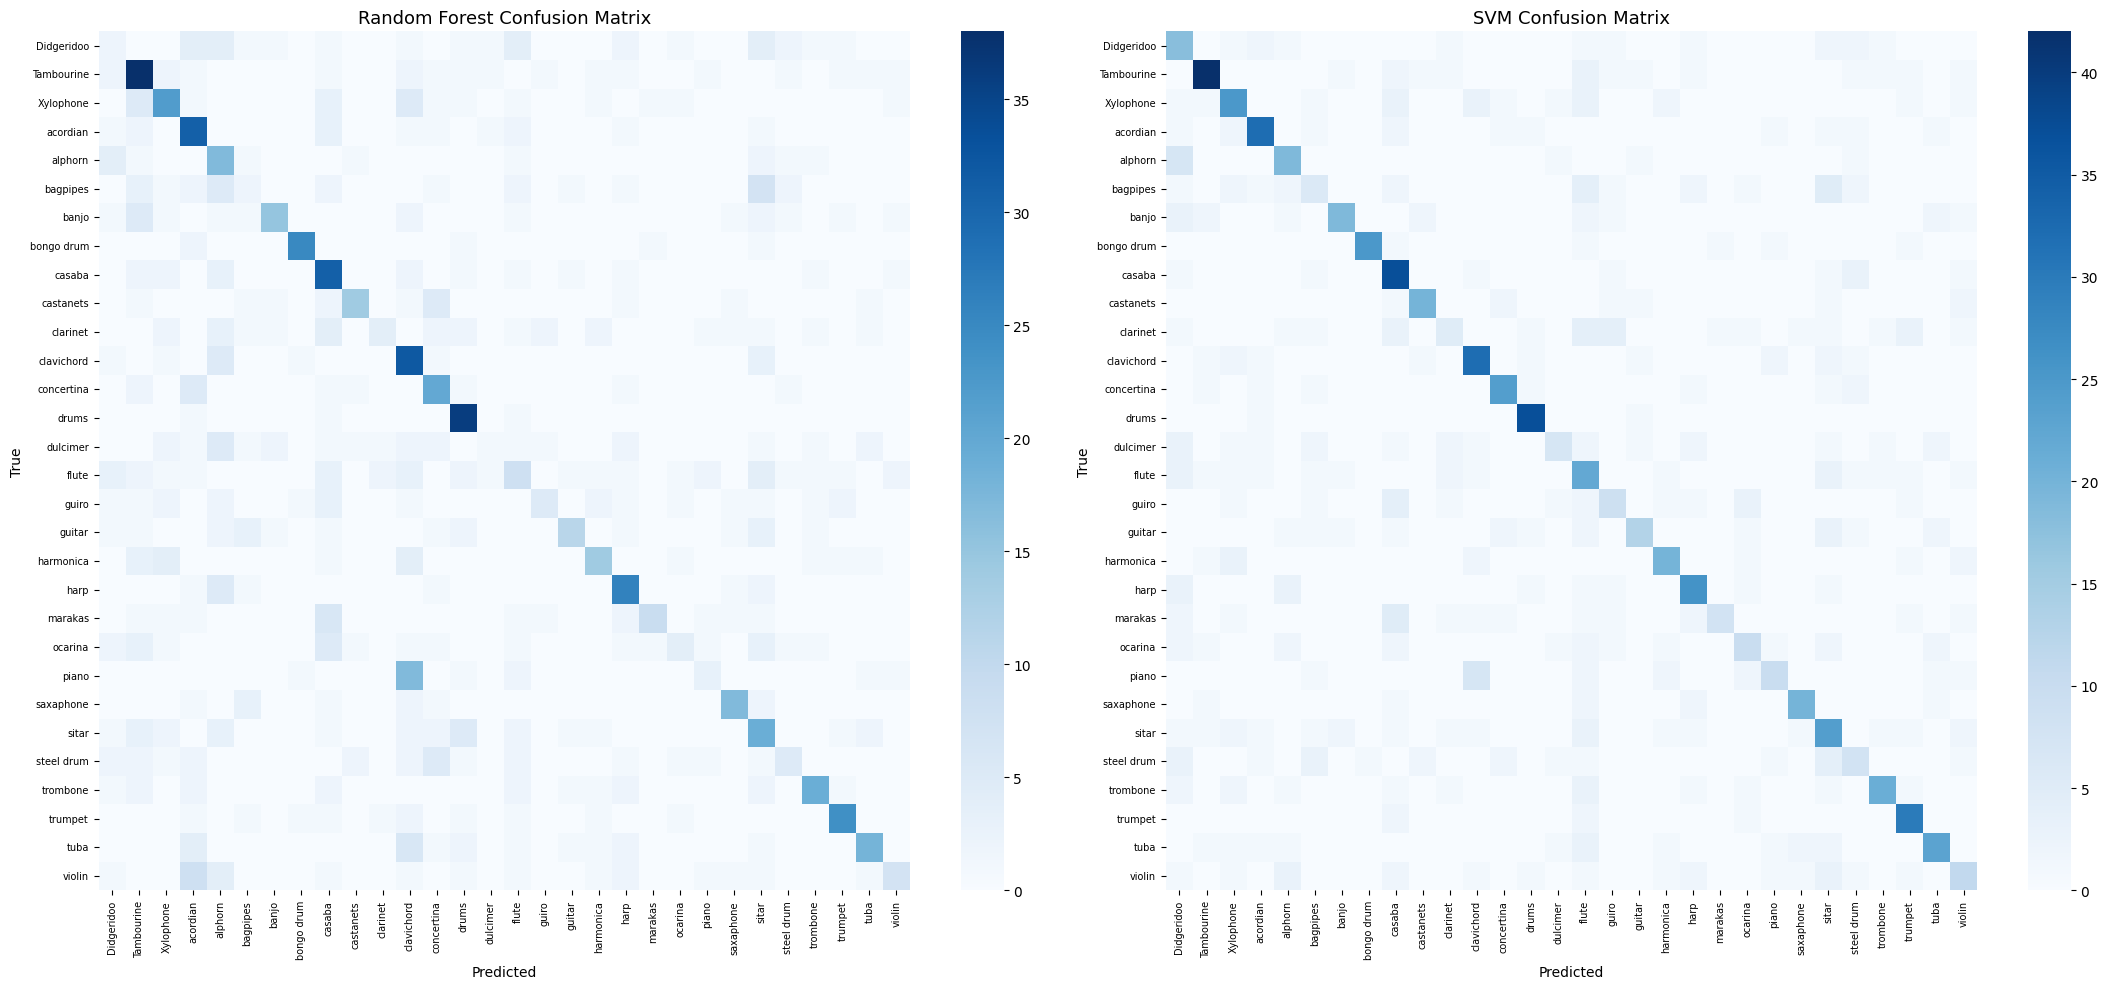

In [ ]:
# ── Detailed Reports ──────────────────────────────────────────────────────────
for name, y_pred in [('Random Forest', y_pred_rf), ('SVM', y_pred_svm)]:
    print(f"\n{'='*60}")
    print(f" {name} — Classification Report")
    print('='*60)
    print(classification_report(y_test_hog, y_pred, target_names=CLASSES))

# ── Confusion Matrix Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
for ax, (name, y_pred) in zip(axes, [('Random Forest', y_pred_rf), ('SVM', y_pred_svm)]):
    cm = confusion_matrix(y_test_hog, y_pred)
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title(f'{name} Confusion Matrix', fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# ── Data Generators (no augmentation yet) ────────────────────────────────────
base_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_gen_plain = base_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='sparse', seed=SEED
)
valid_gen_plain = base_datagen.flow_from_directory(
    VALID_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='sparse', seed=SEED, shuffle=False
)
test_gen_plain = base_datagen.flow_from_directory(
    TEST_DIR,  target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='sparse', seed=SEED, shuffle=False
)

Found 4793 images belonging to 30 classes.
Found 150 images belonging to 30 classes.
Found 150 images belonging to 30 classes.


In [ ]:
def build_plain_cnn(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    """Simple VGG-style CNN — depth, uniform 3x3 filters, no regularisation."""
    model = keras.Sequential([
        # ── Block 1 ───────────────────────────────────────────────────────────
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=(img_size, img_size, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        # ── Block 2 ───────────────────────────────────────────────────────────
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        # ── Block 3 ───────────────────────────────────────────────────────────
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        # ── Classifier ────────────────────────────────────────────────────────
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='PlainCNN')
    return model

plain_cnn = build_plain_cnn()
plain_cnn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
plain_cnn.summary()

Model: "PlainCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,683,582 (33.13 MB)

 Trainable params: 8,683,582 (33.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_plain = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1)
]

history_plain = plain_cnn.fit(
    train_gen_plain,
    validation_data=valid_gen_plain,
    epochs=EPOCHS_CNN,
    callbacks=callbacks_plain,
    verbose=1
)

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.1427 - loss: 3.1019 - val_accuracy: 0.3400 - val_loss: 2.2507 - learning_rate: 0.0010
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.3799 - loss: 2.2747 - val_accuracy: 0.5667 - val_loss: 1.5204 - learning_rate: 0.0010
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.5518 - loss: 1.5902 - val_accuracy: 0.5800 - val_loss: 1.2872 - learning_rate: 0.0010
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.7432 - loss: 0.8796 - val_accuracy: 0.6267 - val_loss: 1.4288 - learning_rate: 0.0010
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8861 - loss: 0.3740 - val_accuracy: 0.6133 - val_loss: 1.8110 - learning_rate: 0.0010
Epoch 6/30
149/150 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9611 - loss: 0.1387
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.9549 - loss: 0.

In [ ]:
_, acc_plain = plain_cnn.evaluate(test_gen_plain, verbose=0)
print(f"Plain CNN — Test Accuracy: {acc_plain:.4f}")

Plain CNN — Test Accuracy: 0.6333


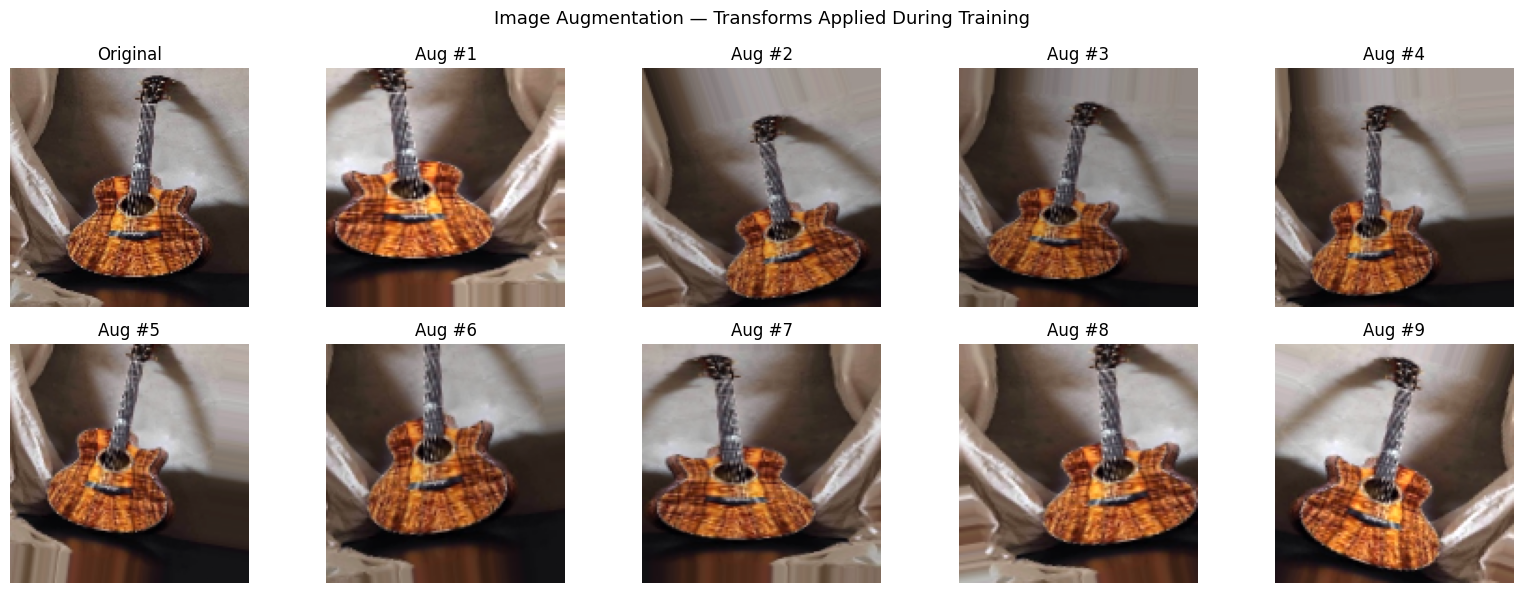

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Visualise Augmentation Transforms ────────────────────────────────────────
aug_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,            # random rotation
    width_shift_range=0.15,       # horizontal shift
    height_shift_range=0.15,      # vertical shift
    shear_range=0.10,             # perspective / tilt
    zoom_range=0.15,              # zooming
    horizontal_flip=True,         # mirroring
    brightness_range=[0.8, 1.2],  # lighting changes
    fill_mode='nearest'
)

# Load one sample image and visualise 8 augmented versions
sample_img = cv2.imread(sample_file)
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
sample_img = cv2.resize(sample_img, (IMG_SIZE, IMG_SIZE))
sample_4d  = np.expand_dims(sample_img, axis=0)  # (1, H, W, 3) - Removed / 255.0 here as ImageDataGenerator will handle it

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
axes[0].imshow(sample_img); axes[0].set_title('Original'); axes[0].axis('off')
aug_iter = aug_datagen.flow(sample_4d, batch_size=1)
for i in range(1, 10):
    aug_img = next(aug_iter)[0]
    axes[i].imshow(np.clip(aug_img, 0, 1))
    axes[i].set_title(f'Aug #{i}')
    axes[i].axis('off')
plt.suptitle('Image Augmentation — Transforms Applied During Training', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Data Generators WITH Augmentation ────────────────────────────────────────
train_gen_aug = aug_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='sparse', seed=SEED
)
valid_gen_aug = ImageDataGenerator(rescale=1.0/255.0).flow_from_directory(
    VALID_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='sparse', seed=SEED, shuffle=False
)
test_gen_aug  = ImageDataGenerator(rescale=1.0/255.0).flow_from_directory(
    TEST_DIR,  target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='sparse', seed=SEED, shuffle=False
)

Found 4793 images belonging to 30 classes.
Found 150 images belonging to 30 classes.
Found 150 images belonging to 30 classes.


In [ ]:
def build_regularised_cnn(num_classes=NUM_CLASSES, img_size=IMG_SIZE, dropout_rate=0.5):
    """Same VGG-style depth as PlainCNN but with Dropout after dense layers."""
    model = keras.Sequential([
        # ── Block 1 ───────────────────────────────────────────────────────────
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=(img_size, img_size, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        # ── Block 2 ───────────────────────────────────────────────────────────
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        # ── Block 3 ───────────────────────────────────────────────────────────
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        # ── Classifier + Dropout ──────────────────────────────────────────────
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout_rate),          # ← Dropout regularisation
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate / 2),      # ← lighter Dropout near output
        layers.Dense(num_classes, activation='softmax')
    ], name='RegularisedCNN')
    return model

reg_cnn = build_regularised_cnn(dropout_rate=0.5)
reg_cnn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
reg_cnn.summary()

Model: "RegularisedCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,712,638 (33.24 MB)

 Trainable params: 8,712,638 (33.24 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_reg = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1)
]

history_reg = reg_cnn.fit(
    train_gen_aug,
    validation_data=valid_gen_aug,
    epochs=EPOCHS_CNN,
    callbacks=callbacks_reg,
    verbose=1
)

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 45s 256ms/step - accuracy: 0.0597 - loss: 3.3644 - val_accuracy: 0.0933 - val_loss: 3.2251 - learning_rate: 0.0010
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 32s 215ms/step - accuracy: 0.0835 - loss: 3.2527 - val_accuracy: 0.1200 - val_loss: 3.1277 - learning_rate: 0.0010
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 225ms/step - accuracy: 0.1001 - loss: 3.1558 - val_accuracy: 0.1333 - val_loss: 2.8715 - learning_rate: 0.0010
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 220ms/step - accuracy: 0.1093 - loss: 3.1154 - val_accuracy: 0.1600 - val_loss: 2.8111 - learning_rate: 0.0010
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 217ms/step - accuracy: 0.1344 - loss: 3.0464 - val_accuracy: 0.2467 - val_loss: 2.5655 - learning_rate: 0.0010
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 33s 223ms/step - accuracy: 0.1435 - loss: 2.9997 - val_accuracy: 0.2333 - val_loss: 2.5412 - learning_rate: 0.0010
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 227ms/step - accuracy: 0.1

In [ ]:
_, acc_reg = reg_cnn.evaluate(test_gen_aug, verbose=0)
print(f"Regularised CNN — Test Accuracy: {acc_reg:.4f}")

Regularised CNN — Test Accuracy: 0.6400


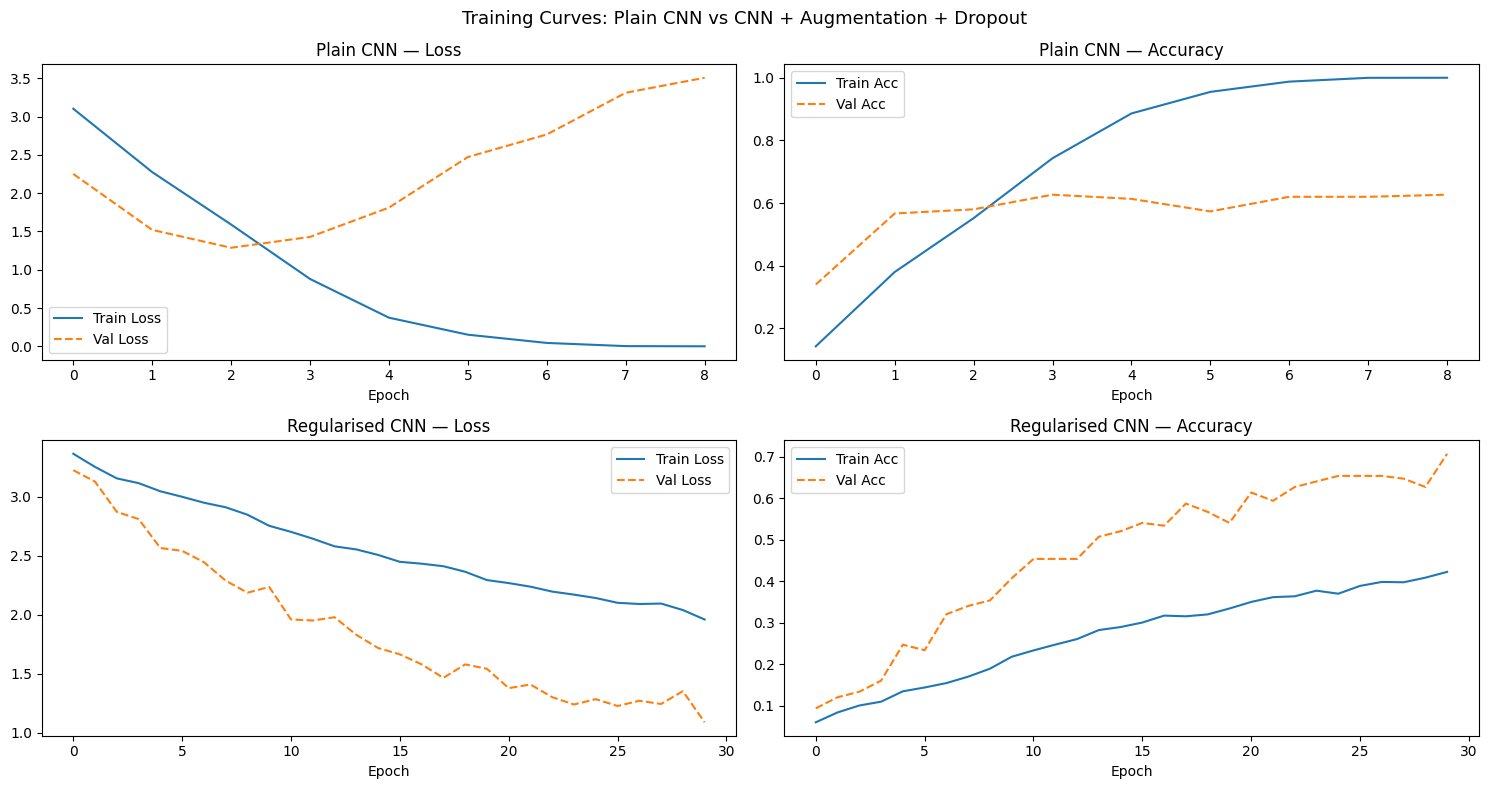

In [ ]:
# ── Training Curve Comparison: Plain vs Regularised ──────────────────────────
def plot_history(h, title, ax_loss, ax_acc):
    ax_loss.plot(h.history['loss'],     label='Train Loss')
    ax_loss.plot(h.history['val_loss'], label='Val Loss',  linestyle='--')
    ax_loss.set_title(f'{title} — Loss');  ax_loss.legend(); ax_loss.set_xlabel('Epoch')
    ax_acc.plot(h.history['accuracy'],     label='Train Acc')
    ax_acc.plot(h.history['val_accuracy'], label='Val Acc',  linestyle='--')
    ax_acc.set_title(f'{title} — Accuracy'); ax_acc.legend(); ax_acc.set_xlabel('Epoch')

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
plot_history(history_plain, 'Plain CNN',        axes[0][0], axes[0][1])
plot_history(history_reg,   'Regularised CNN',  axes[1][0], axes[1][1])
plt.suptitle('Training Curves: Plain CNN vs CNN + Augmentation + Dropout', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def build_mobilenetv2(num_classes=NUM_CLASSES, img_size=IMG_SIZE, dropout=0.3):
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False   # Freeze backbone

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='MobileNetV2_TL'), base

mobilenet_model, mobilenet_base = build_mobilenetv2()
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mobilenet_model.summary()

Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,822 (9.25 MB)

 Trainable params: 167,838 (655.62 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ── Phase 1: Train head only (frozen backbone) ────────────────────────────────
cb_tl = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

history_mb1 = mobilenet_model.fit(
    train_gen_aug,
    validation_data=valid_gen_aug,
    epochs=EPOCHS_TL,
    callbacks=cb_tl,
    verbose=1
)

_, acc_mb1 = mobilenet_model.evaluate(test_gen_aug, verbose=0)
print(f"MobileNetV2 (frozen) — Test Accuracy: {acc_mb1:.4f}")

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 53s 291ms/step - accuracy: 0.6305 - loss: 1.3469 - val_accuracy: 0.9667 - val_loss: 0.1921 - learning_rate: 0.0010
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 201ms/step - accuracy: 0.8266 - loss: 0.5817 - val_accuracy: 0.9733 - val_loss: 0.1024 - learning_rate: 0.0010
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 199ms/step - accuracy: 0.8600 - loss: 0.4697 - val_accuracy: 0.9667 - val_loss: 0.0965 - learning_rate: 0.0010
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 207ms/step - accuracy: 0.8752 - loss: 0.3891 - val_accuracy: 0.9533 - val_loss: 0.1273 - learning_rate: 0.0010
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 198ms/step - accuracy: 0.8967 - loss: 0.3320 - val_accuracy: 0.9667 - val_loss: 0.1212 - learning_rate: 0.0010
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9124 - loss: 0.2832
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 208ms/step - accuracy: 0.904

In [ ]:
# ── Phase 2: Fine-tune top layers of backbone ─────────────────────────────────
mobilenet_base.trainable = True
# Freeze all but the last 30 layers
for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),   # very low LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mb2 = mobilenet_model.fit(
    train_gen_aug,
    validation_data=valid_gen_aug,
    epochs=10,
    callbacks=cb_tl,
    verbose=1
)

_, acc_mobilenet = mobilenet_model.evaluate(test_gen_aug, verbose=0)
print(f"MobileNetV2 (fine-tuned) — Test Accuracy: {acc_mobilenet:.4f}")

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 66s 329ms/step - accuracy: 0.7626 - loss: 0.8280 - val_accuracy: 0.9667 - val_loss: 0.1005 - learning_rate: 1.0000e-05
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 203ms/step - accuracy: 0.8360 - loss: 0.5622 - val_accuracy: 0.9800 - val_loss: 0.0922 - learning_rate: 1.0000e-05
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 205ms/step - accuracy: 0.8615 - loss: 0.4541 - val_accuracy: 0.9733 - val_loss: 0.0797 - learning_rate: 1.0000e-05
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 205ms/step - accuracy: 0.8779 - loss: 0.3924 - val_accuracy: 0.9733 - val_loss: 0.0737 - learning_rate: 1.0000e-05
Epoch 5/10
 73/150 ━━━━━━━━━━━━━━━━━━━━ 16s 211ms/step - accuracy: 0.8872 - loss: 0.3555

In [ ]:
def build_efficientnetb0(num_classes=NUM_CLASSES, img_size=IMG_SIZE, dropout=0.3):
    # EfficientNet expects inputs in [0, 255] range — adjust rescaling
    base = EfficientNetB0(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    inputs  = keras.Input(shape=(img_size, img_size, 3))
    x = layers.Rescaling(scale=255.0)(inputs)  # undo the /255 from generator
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='EfficientNetB0_TL'), base

effnet_model, effnet_base = build_efficientnetb0()
effnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
effnet_model.summary()

In [ ]:
# ── Phase 1: Frozen backbone ──────────────────────────────────────────────────
history_en1 = effnet_model.fit(
    train_gen_aug,
    validation_data=valid_gen_aug,
    epochs=EPOCHS_TL,
    callbacks=cb_tl,
    verbose=1
)

# ── Phase 2: Fine-tune top 20 layers ─────────────────────────────────────────
effnet_base.trainable = True
for layer in effnet_base.layers[:-20]:
    layer.trainable = False

effnet_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_en2 = effnet_model.fit(
    train_gen_aug,
    validation_data=valid_gen_aug,
    epochs=10,
    callbacks=cb_tl,
    verbose=1
)

_, acc_effnet = effnet_model.evaluate(test_gen_aug, verbose=0)
print(f"EfficientNetB0 (fine-tuned) — Test Accuracy: {acc_effnet:.4f}")

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 87s 412ms/step - accuracy: 0.7117 - loss: 1.1703 - val_accuracy: 0.9733 - val_loss: 0.1036 - learning_rate: 0.0010
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 29s 191ms/step - accuracy: 0.8834 - loss: 0.4056 - val_accuracy: 0.9800 - val_loss: 0.0568 - learning_rate: 0.0010
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 28s 189ms/step - accuracy: 0.9103 - loss: 0.3013 - val_accuracy: 0.9933 - val_loss: 0.0496 - learning_rate: 0.0010
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 197ms/step - accuracy: 0.9205 - loss: 0.2499 - val_accuracy: 1.0000 - val_loss: 0.0186 - learning_rate: 0.0010
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 29s 191ms/step - accuracy: 0.9345 - loss: 0.2064 - val_accuracy: 1.0000 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 29s 194ms/step - accuracy: 0.9393 - loss: 0.1908 - val_accuracy: 1.0000 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 197ms/step - accuracy: 0.9

In [ ]:
# ── Summary Table ─────────────────────────────────────────────────────────────
results = {
    'Model': [
        'HOG + Random Forest',
        'HOG + SVM (RBF)',
        'Plain CNN',
        'CNN + Aug + Dropout',
        'MobileNetV2 (TL)',
        'EfficientNetB0 (TL)'
    ],
    'Approach': [
        'Classical ML',
        'Classical ML',
        'CNN from scratch',
        'CNN + Regularisation',
        'Transfer Learning',
        'Transfer Learning'
    ],
    'Test Accuracy': [
        round(acc_rf, 4),
        round(acc_svm, 4),
        round(acc_plain, 4),
        round(acc_reg, 4),
        round(acc_mobilenet, 4),
        round(acc_effnet, 4)
    ],
    'Key Technique': [
        'HOG + Ensemble Trees',
        'HOG + Kernel Trick',
        'Representation Learning',
        'Augmentation + Dropout',
        'Depthwise Sep. Conv',
        'Compound Scaling'
    ]
}

df_results = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(df_results.to_string(index=False))

              Model             Approach  Test Accuracy           Key Technique
   MobileNetV2 (TL)    Transfer Learning         0.9933     Depthwise Sep. Conv
EfficientNetB0 (TL)    Transfer Learning         0.9800        Compound Scaling
          Plain CNN     CNN from scratch         0.6800 Representation Learning
CNN + Aug + Dropout CNN + Regularisation         0.5800  Augmentation + Dropout
    HOG + SVM (RBF)         Classical ML         0.5790      HOG + Kernel Trick
HOG + Random Forest         Classical ML         0.4583    HOG + Ensemble Trees


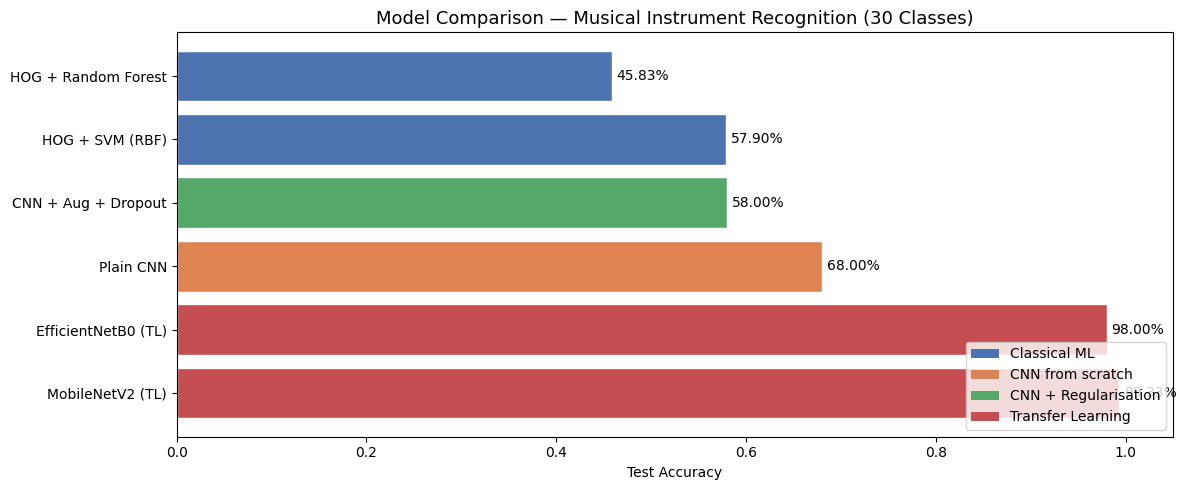

In [ ]:
# ── Bar Chart Comparison ──────────────────────────────────────────────────────
palette = {
    'Classical ML'        : '#4C72B0',
    'CNN from scratch'    : '#DD8452',
    'CNN + Regularisation': '#55A868',
    'Transfer Learning'   : '#C44E52'
}
colors = [palette[a] for a in df_results['Approach']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(df_results['Model'], df_results['Test Accuracy'], color=colors, edgecolor='white')
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Comparison — Musical Instrument Recognition (30 Classes)', fontsize=13)
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, df_results['Test Accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2%}', va='center', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in palette.items()]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

Best model: MobileNetV2 (TL)


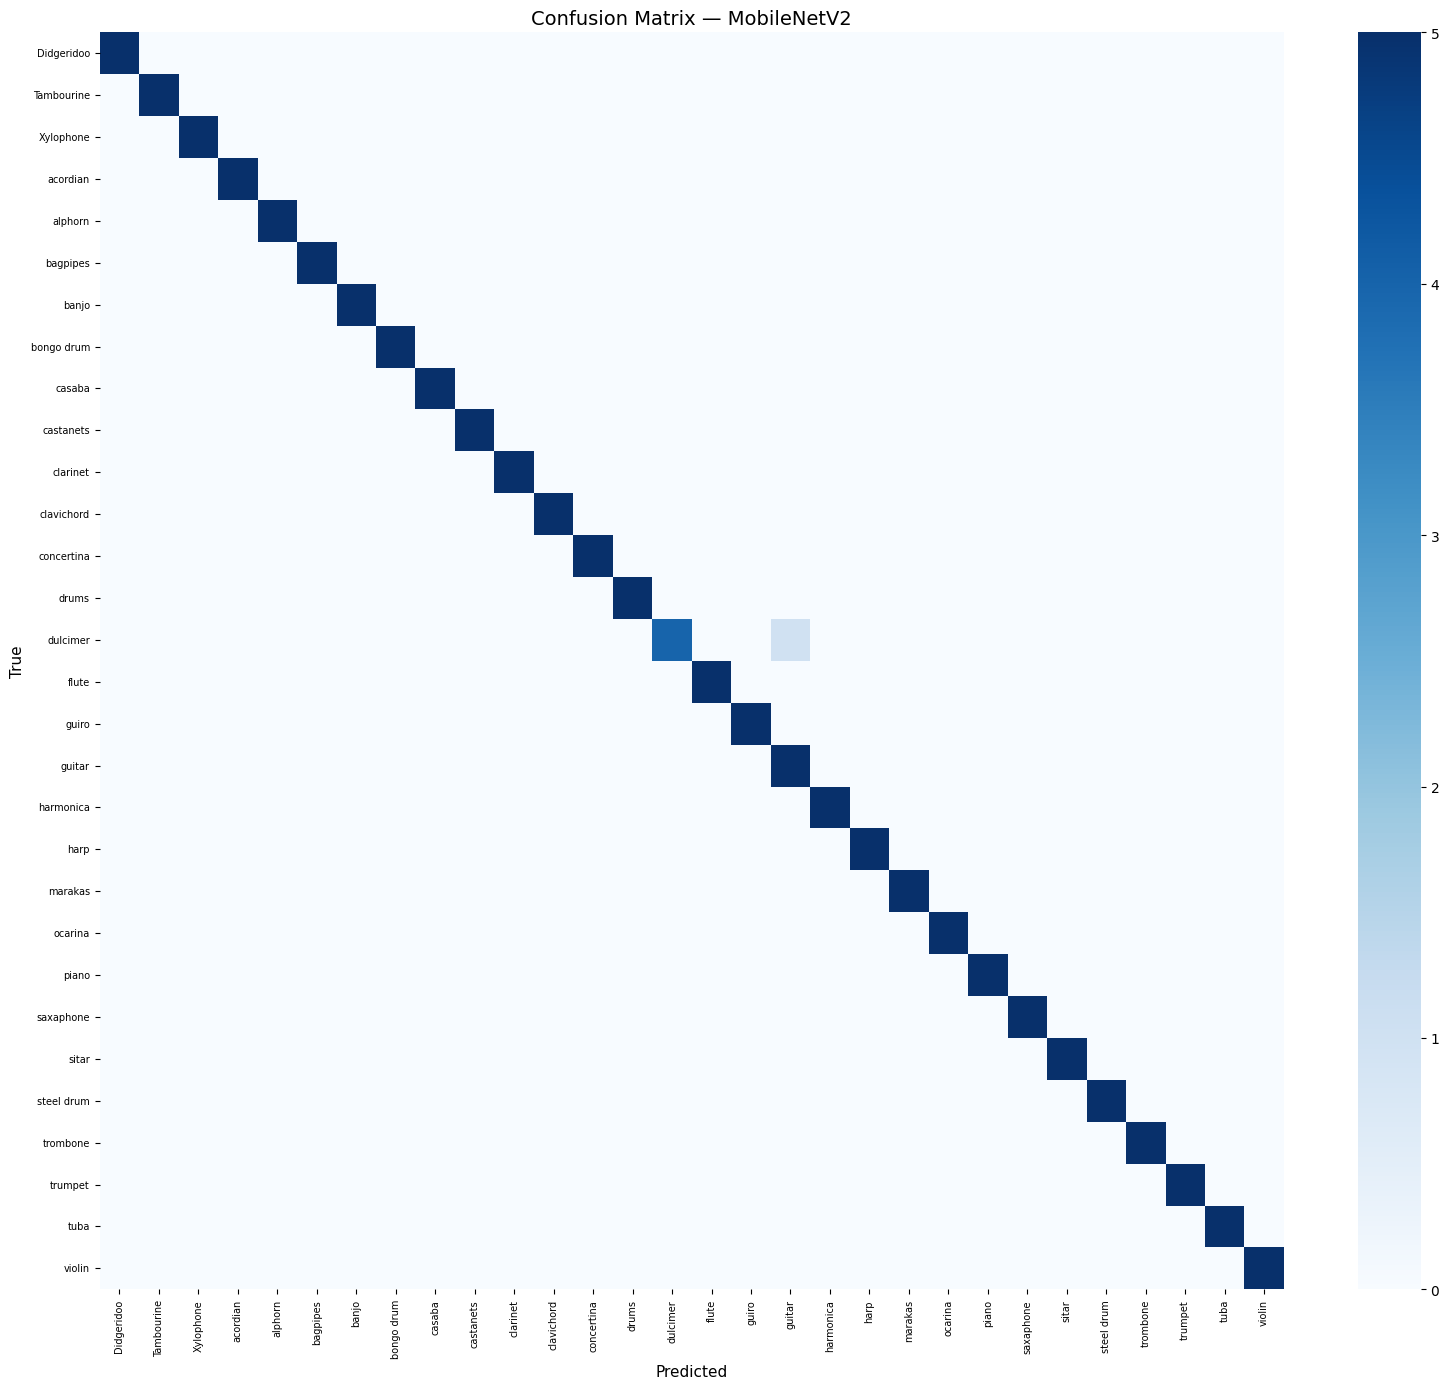


MobileNetV2 Classification Report:
              precision    recall  f1-score   support

  Didgeridoo       1.00      1.00      1.00         5
  Tambourine       1.00      1.00      1.00         5
   Xylophone       1.00      1.00      1.00         5
    acordian       1.00      1.00      1.00         5
     alphorn       1.00      1.00      1.00         5
    bagpipes       1.00      1.00      1.00         5
       banjo       1.00      1.00      1.00         5
  bongo drum       1.00      1.00      1.00         5
      casaba       1.00      1.00      1.00         5
   castanets       1.00      1.00      1.00         5
    clarinet       1.00      1.00      1.00         5
  clavichord       1.00      1.00      1.00         5
  concertina       1.00      1.00      1.00         5
       drums       1.00      1.00      1.00         5
    dulcimer       1.00      0.80      0.89         5
       flute       1.00      1.00      1.00         5
       guiro       1.00      1.00      1.00  

In [ ]:
# ── Confusion Matrix for Best Model ──────────────────────────────────────────
best_model_name = df_results.iloc[0]['Model']
print(f"Best model: {best_model_name}")

# Predict with the best deep learning model (whichever scored highest)
best_dl_acc = max(acc_reg, acc_mobilenet, acc_effnet)
if best_dl_acc == acc_effnet:
    best_dl_model, best_gen = effnet_model, test_gen_aug
    best_dl_name = 'EfficientNetB0'
elif best_dl_acc == acc_mobilenet:
    best_dl_model, best_gen = mobilenet_model, test_gen_aug
    best_dl_name = 'MobileNetV2'
else:
    best_dl_model, best_gen = reg_cnn, test_gen_aug
    best_dl_name = 'Regularised CNN'

best_gen.reset()
y_true_dl, y_pred_dl = [], []
for i in range(len(best_gen)):
    X_batch, y_batch = next(best_gen)
    preds = np.argmax(best_dl_model.predict(X_batch, verbose=0), axis=1)
    y_true_dl.extend(y_batch.astype(int))
    y_pred_dl.extend(preds)

cm_best = confusion_matrix(y_true_dl, y_pred_dl)
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm_best, annot=False, cmap='Blues', ax=ax,
            xticklabels=CLASSES, yticklabels=CLASSES)
ax.set_title(f'Confusion Matrix — {best_dl_name}', fontsize=14)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True',      fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.show()
print(f"\n{best_dl_name} Classification Report:")
print(classification_report(y_true_dl, y_pred_dl, target_names=CLASSES))

Found 150 images belonging to 30 classes.


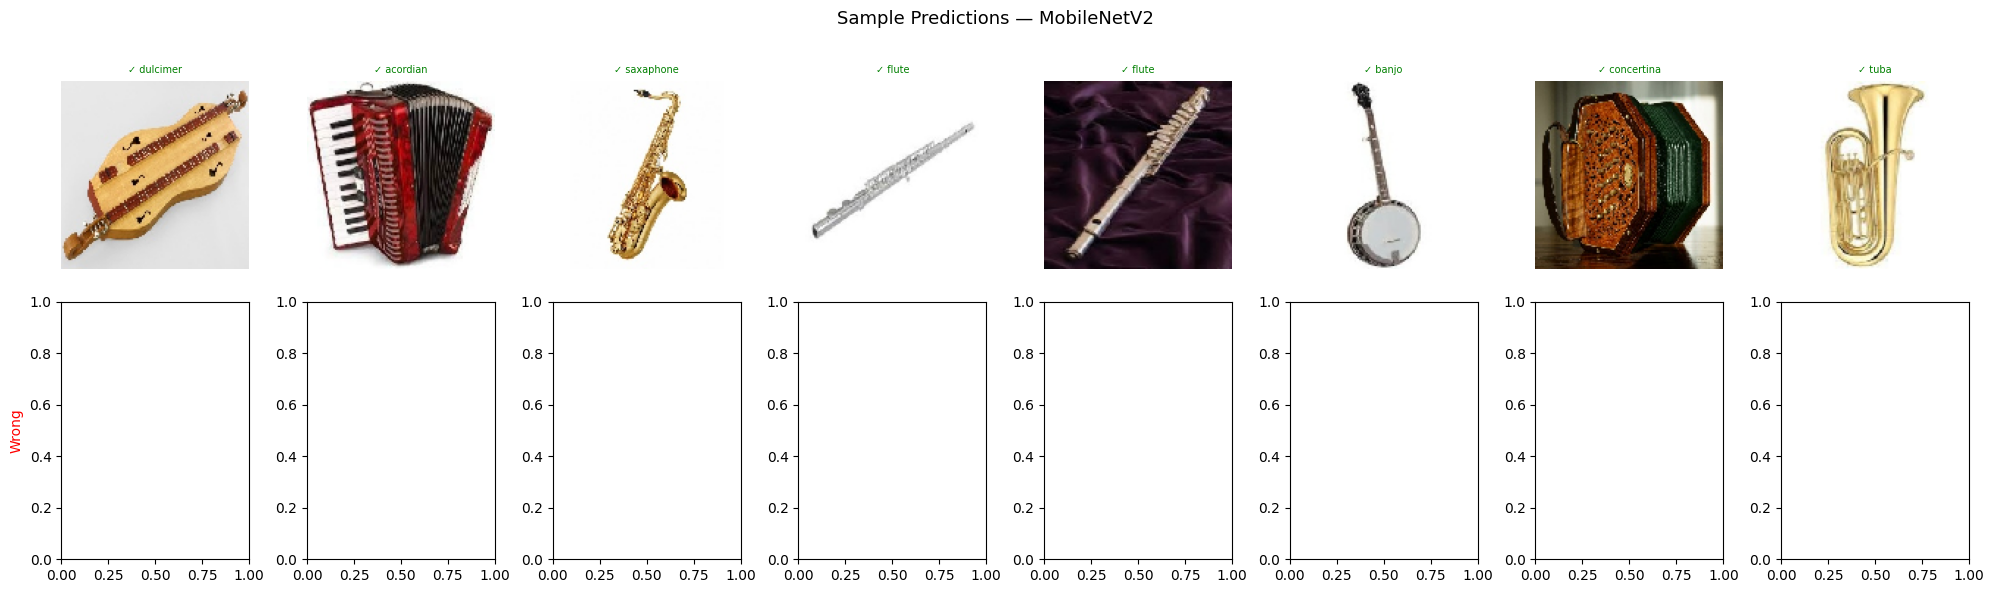

In [ ]:
# ── Visual Predictions: Correct vs Incorrect ──────────────────────────────────
test_gen_vis = ImageDataGenerator(rescale=1.0/255.0).flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64, class_mode='sparse', shuffle=True, seed=SEED
)
X_vis, y_vis = next(test_gen_vis)
preds_vis = np.argmax(best_dl_model.predict(X_vis, verbose=0), axis=1)
y_vis = y_vis.astype(int)

correct_idx   = np.where(preds_vis == y_vis)[0]
incorrect_idx = np.where(preds_vis != y_vis)[0]

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, idx in enumerate(correct_idx[:8]):
    axes[0][i].imshow(X_vis[idx])
    axes[0][i].set_title(f'✓ {CLASSES[preds_vis[idx]]}', fontsize=7, color='green')
    axes[0][i].axis('off')
for i, idx in enumerate(incorrect_idx[:8]):
    axes[1][i].imshow(X_vis[idx])
    axes[1][i].set_title(
        f'✗ pred:{CLASSES[preds_vis[idx]]}\ntrue:{CLASSES[y_vis[idx]]}',
        fontsize=6, color='red'
    )
    axes[1][i].axis('off')

axes[0][0].set_ylabel('Correct', fontsize=10, color='green')
axes[1][0].set_ylabel('Wrong',   fontsize=10, color='red')
plt.suptitle(f'Sample Predictions — {best_dl_name}', fontsize=13)
plt.tight_layout()
plt.show()

---
## 📝 Cell 10 — Conclusion

This project demonstrated the **full progression** of the course curriculum applied to
Musical Instrument Recognition across 30 classes:

### Key Takeaways

| Course Topic | What We Saw |
|---|---|
| **Representation Learning** | CNNs automatically learned features that outperform hand-crafted HOG descriptors |
| **Regularisation — Augmentation** | Artificial data expansion with flips, rotations, brightness shifts reduced overfitting |
| **Regularisation — Dropout** | Randomly zeroing neurons forced robust, redundant feature learning |
| **Depthwise Separable Convolutions** | MobileNetV2 achieved competitive accuracy with ~9× fewer multiply-adds than a plain CNN |
| **Compound Scaling** | EfficientNetB0 balanced depth / width / resolution for optimal accuracy-efficiency trade-off |

### Architecture Evolution Observed
```
HOG+SVM/RF → Plain CNN → CNN+Regularisation → MobileNetV2 → EfficientNetB0
   (low)       (better)      (less overfit)      (efficient)    (best balance)
```

### Potential Improvements
- Add **cutout / cutmix** augmentation (patch erasure)
- Try **EfficientNetB1–B3** for higher accuracy (compound scaling variants)
- Experiment with **label smoothing** loss for 30-class tasks
- Use **learning rate warm-up** with cosine annealing
- Apply **test-time augmentation (TTA)** for inference boosting